In [4]:
# import packages
import pandas as pd
import numpy as np

In [5]:
random_seed = 42

sample_size = 500

temperature = np.random.normal(loc=500, scale=20, size=sample_size)  #kelvin
pressure = np.random.normal(loc=2, scale=0.5, size=sample_size)     #atm
concentration = np.random.uniform(0.1, 1.0, size=sample_size)  # mol/L
catalyst_type = np.random.choice([0, 1], size=sample_size)  #0 for no catalyst and 1 for catalyst

# creating a score point for the sucess column
logit = (
    -2 +
    0.01 * (temperature - 300) +
    0.2 * pressure +
    0.5 * concentration +
    0.3 * catalyst_type
)

prob_success = 1 / (1 + np.exp(-logit))

success = np.random.binomial(1, prob_success)

data = {
    "CHEM ID" : [f'CHEM-{str(i).zfill(3)}' for i in range(1, 501)],
    "temperature (Kel)" : temperature,
    "pressure (atm)": pressure,
    "concentration (mol/L)": concentration,
    "catalyst_type": catalyst_type,
    "success": success
}

df = pd.DataFrame(data)

df.head(10)


,CHEM ID,temperature (Kel),pressure (atm),concentration (mol/L),catalyst_type,success
0,CHEM-001,500.615570,1.935697,0.810747,1,1
1,CHEM-002,530.900450,2.635854,0.704927,1,1
2,CHEM-003,542.987548,1.380904,0.715096,1,1
3,CHEM-004,481.497338,2.015691,0.266402,1,0
4,CHEM-005,527.434552,2.433524,0.288537,1,0
5,CHEM-006,449.139041,2.259347,0.401585,1,1
6,CHEM-007,538.155863,3.089240,0.777750,1,1
7,CHEM-008,508.273533,2.096623,0.636425,0,1
8,CHEM-009,494.650039,2.164494,0.558557,0,0
9,CHEM-010,494.142405,2.111878,0.168526,1,1


<Figure size 640x480 with 0 Axes>

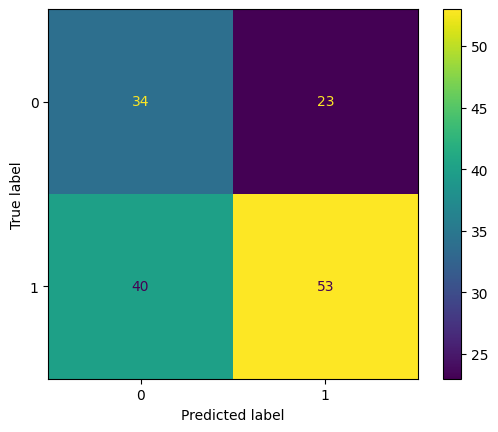

[[34 23]
 [40 53]]
              precision    recall  f1-score   support

           0       0.46      0.60      0.52        57
           1       0.70      0.57      0.63        93

    accuracy                           0.58       150
   macro avg       0.58      0.58      0.57       150
weighted avg       0.61      0.58      0.59       150



In [6]:
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, precision_recall_curve, auc
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

# definig x feature and y target
X = df[['temperature (Kel)', 'pressure (atm)', 'concentration (mol/L)', 'catalyst_type']]
y = df['success']

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.3)

model = LogisticRegression(max_iter=1000, class_weight='balanced')


model.fit(X_train, y_train)

y_pred = model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
plt.savefig('confusion_matrix1.png')
disp.plot()
plt.show()

print(cm)
print(classification_report(y_test, y_pred))


In [7]:
df['success'].value_counts()

success
1    346
0    154
Name: count, dtype: int64

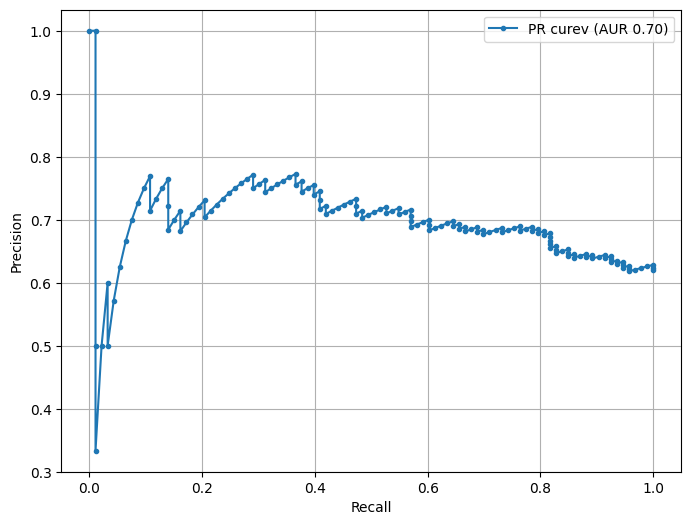

<Figure size 640x480 with 0 Axes>

In [8]:
# get the success of the 1 class
y_prob = model.predict_proba(X_test)[:, 1]

precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

area_under_curve = auc(recall, precision)

# plot the graph to visualize 
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, marker=".", label=f'PR curev (AUR{area_under_curve: .2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend()
plt.grid(True)
plt.show()
plt.savefig('precision_recall_curve.png')


In [9]:
# save the model for connecting with the flask backend
import joblib
joblib.dump(model, 'reaction_model.pkl')

['reaction_model.pkl']

In [15]:
from sklearn.metrics import precision_score, recall_score, accuracy_score, f1_score
import json


y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

# for the metrics
metrics = {
"precison" : precision_score(y_pred, y_test),
"accuracy" : accuracy_score(y_pred, y_test),
"f1" : f1_score(y_pred, y_test),
"recall" : recall_score(y_pred, y_test)
}

# for pr-curve
precision, recall, thresholds =  precision_recall_curve(y_pred, y_prob)
pr_curve = {
    "precision" : precision.tolist(),
    'recall' : recall.tolist()
}

# for the confusion matrix
cm = confusion_matrix(y_pred, y_test).tolist()

# put the data in a json format 
with open("model_results.json", "w") as f: {
    json.dump({"metrics" : metrics, "confusion" : cm, "prcurve" : pr_curve}, f)
}


In [14]:
# saving my generated data to a csv file
df.to_csv('chemical_reactions.csv', index=False)
